In [1]:
!pip install -q datasets transformers matplotlib

import numpy as np, pandas as pd, torch
from datasets import load_dataset
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
ds = load_dataset("Yelp/yelp_review_full")
test = pd.DataFrame(ds["test"].shuffle(seed=42).select(range(5000)))

LABELS = ["sadness", "joy", "love", "anger", "fear", "surprise"]
clf = pipeline("text-classification", model="Ronohcr7/distilbert-emotion",
               top_k=None, truncation=True, max_length=128,
               device=device, batch_size=64)

outs = clf(test["text"].tolist())
print(len(outs), outs[0])

README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…): reconstructing file:   0%|          |  0.00B /  299MB            

yelp_review_full/train-00000-of-00001.pa(…): downloading bytes:           |  0.00B            

yelp_review_full/test-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 23.5MB            

yelp_review_full/test-00000-of-00001.par(…): downloading bytes:           |  0.00B            

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

5000 [{'label': 'LABEL_1', 'score': 0.9855560064315796}, {'label': 'LABEL_3', 'score': 0.00901718158274889}, {'label': 'LABEL_2', 'score': 0.0024800689425319433}, {'label': 'LABEL_5', 'score': 0.0015571971889585257}, {'label': 'LABEL_0', 'score': 0.0009971000254154205}, {'label': 'LABEL_4', 'score': 0.00039246786036528647}]


In [2]:
probs = np.zeros((len(outs), 6))
for i, res in enumerate(outs):
    for r in res:
        probs[i, int(r["label"].split("_")[-1])] = r["score"]

emo = pd.DataFrame(probs, columns=LABELS)
test["emotion"] = emo.idxmax(axis=1)
test["stars"] = test["label"] + 1

print(test["emotion"].value_counts())
tab = pd.crosstab(test["stars"], test["emotion"], normalize="index")[LABELS]
print(tab.round(3))

emotion
joy         2925
anger       1086
sadness      559
love         188
surprise     135
fear         107
Name: count, dtype: int64
emotion  sadness    joy   love  anger   fear  surprise
stars                                                 
1          0.220  0.256  0.016  0.463  0.028     0.016
2          0.165  0.460  0.029  0.292  0.021     0.031
3          0.100  0.625  0.047  0.166  0.032     0.030
4          0.034  0.773  0.052  0.097  0.015     0.028
5          0.038  0.821  0.043  0.059  0.010     0.029


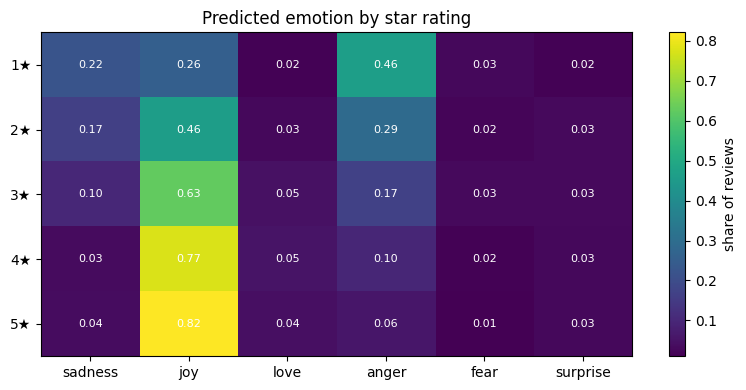

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.imshow(tab.values, aspect="auto", cmap="viridis")
plt.xticks(range(6), LABELS)
plt.yticks(range(5), ["1★", "2★", "3★", "4★", "5★"])
plt.colorbar(label="share of reviews")
plt.title("Predicted emotion by star rating")
for i in range(5):
    for j in range(6):
        plt.text(j, i, f"{tab.values[i, j]:.2f}", ha="center", va="center", color="white", fontsize=8)
plt.tight_layout()
plt.show()